In [18]:
import random
import numpy as np
from pathlib import Path
from the_well.data import WellDataset

import torch
from torch.utils.data import DataLoader

from modules import *
from losses import *
from datasets import TRMDataset

In [27]:
from vis_tools import *

In [19]:
SEED         = 42
EPOCHS       = 15
BATCH_SIZE   = 32
LR           = 1e-3

BASE_PATH = "/mnt/storage_C1/BILL_pino"
DATASET_NAME = "turbulent_radiative_layer_2D"
DATASET_PATH = BASE_PATH + "/the_well/datasets/" + DATASET_NAME
OUTPUT_DIR   = BASE_PATH + '/models/' + DATASET_NAME

MODES1       = 16   # Modos de Fourier na primeira dimensão espacial (x)
MODES2       = 16   # Modos de Fourier na segunda dimensão espacial (y)
WIDTH        = 32   # Número de canais internos (largura do modelo)
DEPTH        = 4    # Quantidade de camadas de Fourier
PROJ_DIM     = 128  # Dimensão da MLP de projeção para a saída

In [3]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")
print(f"Torch: {torch.__version__}  |  Torchvision: {__import__('torchvision').__version__}")

Dispositivo: cuda
Torch: 2.11.0+cu128  |  Torchvision: 0.26.0+cu128


In [14]:
train_dataset = WellDataset(
    path=DATASET_PATH,
    well_split_name="train"
)

validation_dataset = WellDataset(
    path=DATASET_PATH,
    well_split_name="valid"
)

train_ds = TRMDataset(train_dataset)
val_ds = TRMDataset(validation_dataset)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=12,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=4,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=False,
    prefetch_factor=4,
)

### Teste 1

In [6]:
x, y = train_ds[0]
in_dim, out_dim = x.shape[-1], y.shape[-1] 

model = FNO2d(
    modes1=MODES1,
    modes2=MODES2,
    width=WIDTH,
    in_dim=in_dim,
    out_dim=out_dim,
    depth=DEPTH,
    proj_dim=PROJ_DIM
).cuda()
model = torch.compile(model)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
)

criterion = relative_l2_loss

In [10]:
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=EPOCHS,
    checkpoint_dir=OUTPUT_DIR,
    label = 'trl2d_teste1'
)

Epoch 1/15: 100%|██████████| 225/225 [00:38<00:00,  5.85it/s, loss=0.214092]


Epoch 001 | train = 0.214092 | val = 0.114805 | best_val = 0.114805


Epoch 2/15: 100%|██████████| 225/225 [00:37<00:00,  5.95it/s, loss=0.107613]


Epoch 002 | train = 0.107613 | val = 0.109554 | best_val = 0.109554


Epoch 3/15: 100%|██████████| 225/225 [00:38<00:00,  5.83it/s, loss=0.103003]


...

Epoch 013 | train = 0.087023 | val = 0.100978 | best_val = 0.100978


Epoch 14/15: 100%|██████████| 225/225 [00:38<00:00,  5.82it/s, loss=0.086587]


Epoch 014 | train = 0.086587 | val = 0.100951 | best_val = 0.100951


Epoch 15/15: 100%|██████████| 225/225 [00:38<00:00,  5.84it/s, loss=0.086358]


Epoch 015 | train = 0.086358 | val = 0.100948 | best_val = 0.100948


In [29]:
from vis_tools import *

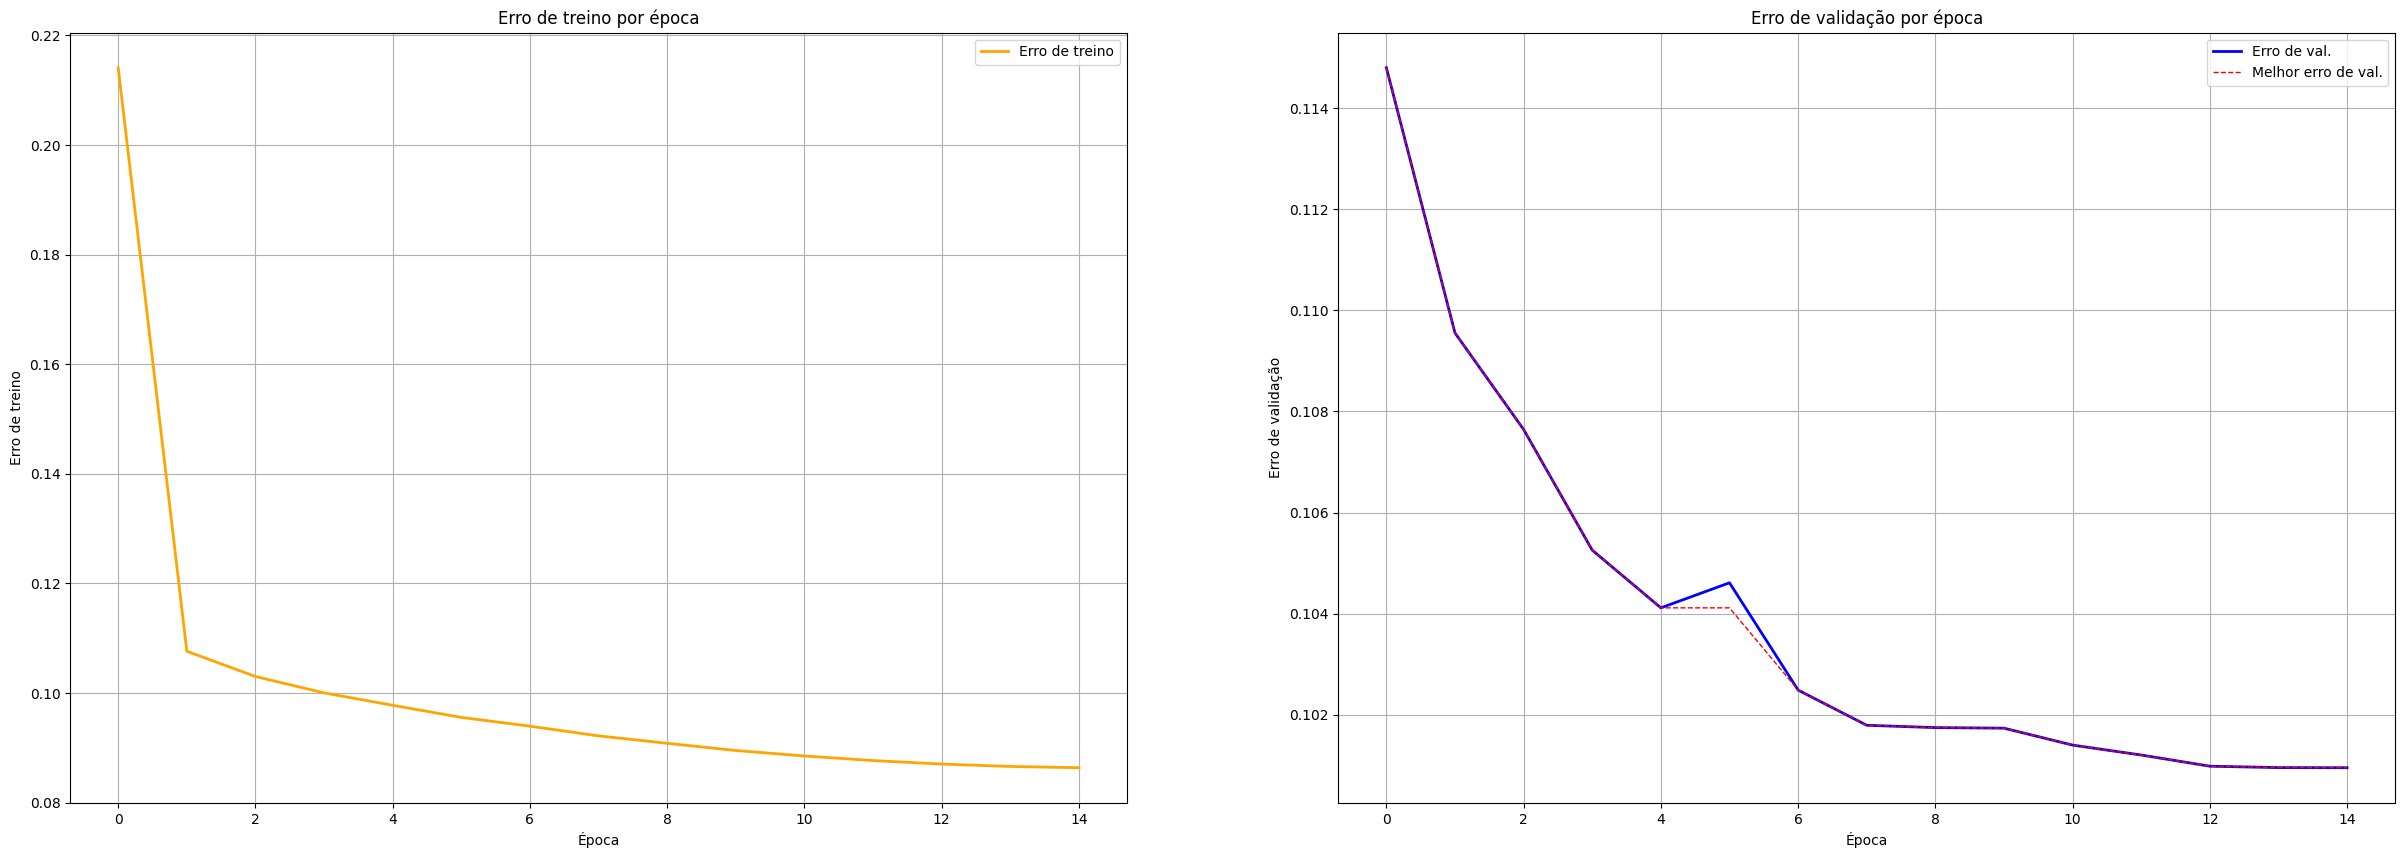

In [11]:
from vis_tools import *

temp = plot(history)

temp.show()

Resultado Teste 1

| train = 0.080893 | val = 0.098307 | best_val = 0.098307

In [37]:
import imageio.v2 as imageio
import matplotlib.pyplot as plt
from io import BytesIO

model.eval()

frames = []

for i in range(100):

    x, y = val_ds[i]

    with torch.no_grad():
        pred = model(x.unsqueeze(0).to(device))

    pred = pred.squeeze(0).cpu().numpy()

    y = y.cpu().numpy()

    fig, ax = plt.subplots(1,2, figsize=(12,4))

    ax[0].imshow(y[:,:,0])
    ax[0].set_title("Truth")

    ax[1].imshow(pred[:,:,0])
    ax[1].set_title("Prediction")

    buf = BytesIO()
    plt.savefig(buf, format="png")
    plt.close()

    buf.seek(0)
    frames.append(imageio.imread(buf))

imageio.mimsave("comparison.gif", frames, fps=10)

### Teste 2

In [38]:
x, y = train_ds[0]
in_dim, out_dim = x.shape[-1], y.shape[-1] 

model = FNO2d_v1(
    modes1=MODES1,
    modes2=MODES2,
    width=WIDTH,
    width1= WIDTH,
    in_dim=in_dim,
    out_dim=out_dim,
    depth=DEPTH,
    proj_dim=PROJ_DIM
).cuda()
model = torch.compile(model)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
)

criterion = relative_l2_loss

In [41]:
history2 = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=EPOCHS,
    checkpoint_dir=OUTPUT_DIR,
    label = 'trl2d_teste2'
)

Epoch 1/15: 100%|██████████| 225/225 [00:46<00:00,  4.80it/s, loss=0.431614]


Epoch 001 | train = 0.431614 | val = 0.114410 | best_val = 0.114410


Epoch 2/15: 100%|██████████| 225/225 [00:43<00:00,  5.19it/s, loss=0.104735]


Epoch 002 | train = 0.104735 | val = 0.105373 | best_val = 0.105373


Epoch 3/15: 100%|██████████| 225/225 [00:38<00:00,  5.79it/s, loss=0.098248]


...

Epoch 013 | train = 0.067583 | val = 0.082836 | best_val = 0.082836


Epoch 14/15: 100%|██████████| 225/225 [00:36<00:00,  6.08it/s, loss=0.066851]


Epoch 014 | train = 0.066851 | val = 0.082614 | best_val = 0.082614


Epoch 15/15: 100%|██████████| 225/225 [00:36<00:00,  6.11it/s, loss=0.066476]


Epoch 015 | train = 0.066476 | val = 0.082625 | best_val = 0.082614


In [42]:
import imageio.v2 as imageio
import matplotlib.pyplot as plt
from io import BytesIO

model.eval()

frames = []

for i in range(100):

    x, y = val_ds[i]

    with torch.no_grad():
        pred = model(x.unsqueeze(0).to(device))

    pred = pred.squeeze(0).cpu().numpy()

    y = y.cpu().numpy()

    fig, ax = plt.subplots(1,2, figsize=(12,4))

    ax[0].imshow(y[:,:,0])
    ax[0].set_title("Truth")

    ax[1].imshow(pred[:,:,0])
    ax[1].set_title("Prediction")

    buf = BytesIO()
    plt.savefig(buf, format="png")
    plt.close()

    buf.seek(0)
    frames.append(imageio.imread(buf))

imageio.mimsave("comparison2.gif", frames, fps=10)

Resultado teste 2

Epoch 015 | train = 0.057624 | val = 0.074753 | best_val = 0.074753

### Teste 3

In [ ]:
x, y = train_ds[0]
in_dim, out_dim = x.shape[-1], y.shape[-1] 

model = FNO2d_v1(
    modes1=MODES1,
    modes2=MODES2,
    width=WIDTH,
    in_dim=in_dim,
    out_dim=out_dim,
    depth=DEPTH+1,
    proj_dim=192
).cuda()
model = torch.compile(model)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
)

criterion = relative_l2_loss

In [45]:
history3 = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=EPOCHS,
    checkpoint_dir=OUTPUT_DIR
)

Epoch 1/15: 100%|██████████| 225/225 [00:56<00:00,  3.99it/s, loss=0.396451]


Epoch 001 | train = 0.396451 | val = 0.113426 | best_val = 0.113426


Epoch 2/15: 100%|██████████| 225/225 [00:46<00:00,  4.89it/s, loss=0.103854]


Epoch 002 | train = 0.103854 | val = 0.106333 | best_val = 0.106333


Epoch 3/15: 100%|██████████| 225/225 [00:45<00:00,  4.91it/s, loss=0.097523]


...

Epoch 013 | train = 0.063407 | val = 0.081772 | best_val = 0.081772


Epoch 14/15: 100%|██████████| 225/225 [00:45<00:00,  4.92it/s, loss=0.062557]


Epoch 014 | train = 0.062557 | val = 0.081717 | best_val = 0.081717


Epoch 15/15: 100%|██████████| 225/225 [00:45<00:00,  4.91it/s, loss=0.062067]


Epoch 015 | train = 0.062067 | val = 0.081622 | best_val = 0.081622


In [5]:
import imageio.v2 as imageio
import matplotlib.pyplot as plt
from io import BytesIO

model.eval()

frames = []

for i in range(100):

    x, y = val_ds[i]

    with torch.no_grad():
        pred = model(x.unsqueeze(0).to(device))

    pred = pred.squeeze(0).cpu().numpy()

    y = y.cpu().numpy()

    fig, ax = plt.subplots(1,2, figsize=(12,4))

    ax[0].imshow(y[:,:,0])
    ax[0].set_title("Truth")

    ax[1].imshow(pred[:,:,0])
    ax[1].set_title("Prediction")

    buf = BytesIO()
    plt.savefig(buf, format="png")
    plt.close()

    buf.seek(0)
    frames.append(imageio.imread(buf))

imageio.mimsave("comparison3.gif", frames, fps=10)

ModuleNotFoundError: No module named 'imageio'

Resultado teste 3

Epoch 015 | train = 0.051988 | val = 0.072924 | best_val = 0.072857

# Teste 4

In [11]:
x, y = train_ds[0]
in_dim, out_dim = x.shape[-1], y.shape[-1] 

model = DoubleSkipFNO2d(
    modes1=MODES1,
    modes2=MODES2,
    width=WIDTH,
    in_dim=in_dim,
    out_dim=out_dim,
    depth=DEPTH+1,
    proj_dim=192,
    mlp_depth=2
).cuda()

#model = torch.compile(model)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
)

criterion = relative_l2_loss

In [13]:
import imageio.v2 as imageio
import matplotlib.pyplot as plt
from io import BytesIO

model.eval()

frames = []

for i in range(100):

    x, y = val_ds[i]

    with torch.no_grad():
        pred = model(x.unsqueeze(0).to(device))

    pred = pred.squeeze(0).cpu().numpy()

    y = y.cpu().numpy()

    fig, ax = plt.subplots(2,2, figsize=(12,4))

    ax[0][0].imshow(y[:,:,0])
    ax[0][0].set_title("Truth")

    ax[0][1].imshow(pred[:,:,0])
    ax[0][1].set_title("Prediction")

    ax[1][0].imshow(np.abs(y[:,:,0] - y[:, :, 1]), cmap='gnuplot')
    ax[1][0].set_title("Error")

    ax[0][1].imshow(pred[:,:,0])
    ax[0][1].set_title("Loss")

    buf = BytesIO()
    plt.savefig(buf, format="png")
    plt.close()

    buf.seek(0)
    frames.append(imageio.imread(buf))

imageio.mimsave("comparison5.gif", frames, fps=10)

In [12]:
history4 = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=EPOCHS,
    checkpoint_dir=OUTPUT_DIR,
    label='doubleskiptrl'
)

Epoch 1/15: 100%|██████████| 225/225 [01:49<00:00,  2.06it/s, loss=0.272355]


Epoch 001 | train = 0.272355 | val = 0.116281 | best_val = 0.116281


Epoch 2/15: 100%|██████████| 225/225 [01:49<00:00,  2.06it/s, loss=0.108169]


Epoch 002 | train = 0.108169 | val = 0.109210 | best_val = 0.109210


Epoch 3/15: 100%|██████████| 225/225 [01:34<00:00,  2.38it/s, loss=0.102842]


...

Epoch 013 | train = 0.068624 | val = 0.103307 | best_val = 0.101900


Epoch 14/15: 100%|██████████| 225/225 [01:32<00:00,  2.42it/s, loss=0.067269]


Epoch 014 | train = 0.067269 | val = 0.103524 | best_val = 0.101900


Epoch 15/15: 100%|██████████| 225/225 [01:44<00:00,  2.15it/s, loss=0.066533]


Epoch 015 | train = 0.066533 | val = 0.103681 | best_val = 0.101900


# teste 5

In [15]:
x, y = train_ds[0]
in_dim, out_dim = x.shape[-1], y.shape[-1] 

model = BackbonePreFNO2d(
    modes1=MODES1,
    modes2=MODES2,
    width=WIDTH,
    in_dim=in_dim,
    out_dim=out_dim,
    depth=DEPTH+1,
    proj_dim=192,
    mlp_depth=2,
    mlp_width=384
).cuda()

#model = torch.compile(model)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
)

criterion = relative_l2_loss

In [16]:
history5 = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=EPOCHS,
    checkpoint_dir=OUTPUT_DIR,
    label='backbonepreactrl'
)

Epoch 1/15: 100%|██████████| 225/225 [01:29<00:00,  2.51it/s, loss=0.203185]


Epoch 001 | train = 0.203185 | val = 0.135744 | best_val = 0.135744


Epoch 2/15: 100%|██████████| 225/225 [01:58<00:00,  1.90it/s, loss=0.122481]


Epoch 002 | train = 0.122481 | val = 0.122067 | best_val = 0.122067


Epoch 3/15: 100%|██████████| 225/225 [01:52<00:00,  2.00it/s, loss=0.112265]


...

Epoch 013 | train = 0.078400 | val = 0.104456 | best_val = 0.104307


Epoch 14/15: 100%|██████████| 225/225 [02:41<00:00,  1.40it/s, loss=0.077603]


Epoch 014 | train = 0.077603 | val = 0.104544 | best_val = 0.104307


Epoch 15/15: 100%|██████████| 225/225 [02:46<00:00,  1.35it/s, loss=0.077190]


Epoch 015 | train = 0.077190 | val = 0.104519 | best_val = 0.104307


In [17]:
import imageio.v2 as imageio
import matplotlib.pyplot as plt
from io import BytesIO

model.eval()

frames = []

for i in range(100):

    x, y = val_ds[i]

    with torch.no_grad():
        pred = model(x.unsqueeze(0).to(device))

    pred = pred.squeeze(0).cpu().numpy()

    y = y.cpu().numpy()

    fig, ax = plt.subplots(2,2, figsize=(12,4))

    ax[0][0].imshow(y[:,:,0])
    ax[0][0].set_title("Truth")

    ax[0][1].imshow(pred[:,:,0])
    ax[0][1].set_title("Prediction")

    ax[1][0].imshow(np.abs(y[:,:,0] - y[:, :, 1]), cmap='gnuplot')
    ax[1][0].set_title("Error")

    ax[0][1].imshow(pred[:,:,0])
    ax[0][1].set_title("Loss")

    buf = BytesIO()
    plt.savefig(buf, format="png")
    plt.close()

    buf.seek(0)
    frames.append(imageio.imread(buf))

imageio.mimsave("comparison5.gif", frames, fps=10)

In [40]:
import importlib
import vis_tools

importlib.reload(vis_tools)

<module 'vis_tools' from '/home/al.lucas.goncalves/ml2/AV2_ML2_IMPA/vis_tools.py'>

In [41]:
teste = vis_tools.gif(val_ds, model, 'teste_silversson', device)

In [42]:
teste.show(steps=20)

# teste 6